In [11]:
!pip install pandas numpy yfinance xgboost scikit-learn matplotlib

In [12]:
import warnings

import numpy as np
import pandas as pd
import yfinance as yf
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


print("Fetching NIFTY 50 ETF hourly data...")

df = yf.download(
    "NIFTYBEES.NS",
    interval="60m",
    period="2y",
    auto_adjust=False,
    progress=True
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.dropna(inplace=True)

print(f"Downloaded {len(df)} hourly bars.")


print("Calculating technical indicators...")

# Relative volume
df["Volume_MA20"] = df["Volume"].rolling(20).mean()

df["Relative_Volume"] = np.where(
    df["Volume_MA20"] > 0,
    df["Volume"] / df["Volume_MA20"],
    1.0
)


# Average True Range (ATR)
previous_close = df["Close"].shift(1)

high_low = df["High"] - df["Low"]
high_previous_close = (df["High"] - previous_close).abs()
low_previous_close = (df["Low"] - previous_close).abs()

true_range = pd.concat(
    [high_low, high_previous_close, low_previous_close],
    axis=1
).max(axis=1)

df["ATR"] = true_range.rolling(14).mean()


# Relative Strength Index (RSI)
price_change = df["Close"].diff()

gain = price_change.clip(lower=0)
loss = -price_change.clip(upper=0)

average_gain = gain.rolling(14).mean()
average_loss = loss.rolling(14).mean()

relative_strength = average_gain / average_loss

df["RSI"] = 100 - (
    100 / (1 + relative_strength)
)


# Target: whether the next 15-minute close is higher
df["Next_Close"] = df["Close"].shift(-1)

df["Target"] = (
    df["Next_Close"] > df["Close"]
).astype(int)


# Remove rows created by rolling calculations and shifting
df.dropna(inplace=True)


print(f"Trading bars available for ML: {len(df)}")


# Features used by the model
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "Relative_Volume",
    "ATR",
    "RSI"
]

X = df[features]
y = df["Target"]


print("Splitting data chronologically...")

# Time-series data should not be randomly shuffled.
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")


print("\nTraining XGBoost model...")

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)


print("Model trained successfully.")


# Generate predictions only for the unseen test data.
test_probabilities = model.predict_proba(X_test)[:, 1]

df_test = df.iloc[split_index:].copy()
df_test["Prob_UP"] = test_probabilities


print("Generating trading decisions...")


CONFIDENCE_THRESHOLD = 0.55
LIQUIDITY_THRESHOLD = 1.0

probability_up = df_test["Prob_UP"]
relative_volume = df_test["Relative_Volume"]


# Start with WAIT for every test observation.
df_test["Action"] = "WAIT"
df_test["Signal"] = 0.0


# BUY when the model is sufficiently confident
# and trading volume is at least its recent average.
buy_condition = (
    (probability_up > CONFIDENCE_THRESHOLD)
    & (relative_volume >= LIQUIDITY_THRESHOLD)
)

df_test.loc[buy_condition, "Action"] = "BUY"
df_test.loc[buy_condition, "Signal"] = 1.0


# SELL when the model predicts a sufficiently high
# probability of the price moving down.
sell_condition = (
    (probability_up < 1 - CONFIDENCE_THRESHOLD)
    & (relative_volume >= LIQUIDITY_THRESHOLD)
)

df_test.loc[sell_condition, "Action"] = "SELL"
df_test.loc[sell_condition, "Signal"] = -1.0


# Reduce position size when the model is confident
# but the available volume is below its recent average.
reduce_condition = (
    (
        (probability_up > CONFIDENCE_THRESHOLD)
        | (probability_up < 1 - CONFIDENCE_THRESHOLD)
    )
    & (relative_volume < LIQUIDITY_THRESHOLD)
)

df_test.loc[reduce_condition, "Action"] = "REDUCE SIZE"

df_test.loc[reduce_condition, "Signal"] = np.where(
    probability_up[reduce_condition] > 0.5,
    0.5,
    -0.5
)


print("\n--- Model and Decision Controller Complete ---")

print("\nTest-set decisions:")
print(df_test["Action"].value_counts())

Fetching NIFTY 50 ETF hourly data...


[*********************100%***********************]  1 of 1 completed

Downloaded 3449 hourly bars.
Calculating technical indicators...
Trading bars available for ML: 3429
Splitting data chronologically...
Training samples: 2743
Testing samples:  686

Training XGBoost model...
Model trained successfully.
Generating trading decisions...

--- Model and Decision Controller Complete ---

Test-set decisions:
Action
WAIT           394
REDUCE SIZE    169
SELL            94
BUY             29
Name: count, dtype: int64


In [13]:
print("Training the XGBoost machine learning model...")

# Select the variables used by the model.
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "Relative_Volume",
    "ATR",
    "RSI"
]

X = df[features]
y = df["Target"]


# Keep the time order intact.
# The first 80% is used for training and the remaining 20% for testing.
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


# Create and train the XGBoost classifier.
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")


# Generate probabilities only for the unseen test data.
test_probabilities = model.predict_proba(X_test)[:, 1]

test_data = df.iloc[split_index:].copy()
test_data["Prob_UP"] = test_probabilities


print("Generating trading decisions...")


# Decision thresholds
CONFIDENCE_THRESHOLD = 0.55
LIQUIDITY_THRESHOLD = 1.0


probability_up = test_data["Prob_UP"]
relative_volume = test_data["Relative_Volume"]


# Start every observation as WAIT.
test_data["Action"] = "WAIT"
test_data["Signal"] = 0.0


# BUY:
# The model predicts an upward move with sufficient confidence
# and current volume is at least the recent average.
buy_condition = (
    (probability_up > CONFIDENCE_THRESHOLD)
    & (relative_volume >= LIQUIDITY_THRESHOLD)
)

test_data.loc[buy_condition, "Action"] = "BUY"
test_data.loc[buy_condition, "Signal"] = 1.0


# SELL:
# The model predicts a downward move with sufficient confidence
# and current volume is at least the recent average.
sell_condition = (
    (probability_up < 1 - CONFIDENCE_THRESHOLD)
    & (relative_volume >= LIQUIDITY_THRESHOLD)
)

test_data.loc[sell_condition, "Action"] = "SELL"
test_data.loc[sell_condition, "Signal"] = -1.0


# REDUCE SIZE:
# The model is confident, but liquidity is below the threshold.
reduce_condition = (
    (
        (probability_up > CONFIDENCE_THRESHOLD)
        | (probability_up < 1 - CONFIDENCE_THRESHOLD)
    )
    & (relative_volume < LIQUIDITY_THRESHOLD)
)

test_data.loc[reduce_condition, "Action"] = "REDUCE SIZE"

test_data.loc[reduce_condition, "Signal"] = np.where(
    probability_up[reduce_condition] > 0.5,
    0.5,
    -0.5
)


print("\n--- Model and Decision Controller Complete ---")
print("\nTest-set decisions:")
print(test_data["Action"].value_counts())

Training the XGBoost machine learning model...
Training samples: 2743
Testing samples: 686
Model trained successfully.
Generating trading decisions...

--- Model and Decision Controller Complete ---

Test-set decisions:
Action
WAIT           394
REDUCE SIZE    169
SELL            94
BUY             29
Name: count, dtype: int64


In [14]:
print("Backtest rows:", len(backtest))
print("Start:", backtest.index.min())
print("End:", backtest.index.max())

print("\nFinal equity values:")
print("Buy & Hold:", backtest["Buy_Hold_Equity"].iloc[-1])
print("ML:", backtest["ML_Equity"].iloc[-1])
print("Controller:", backtest["Controller_Equity"].iloc[-1])

print("\nCalculated returns:")
print(
    "Buy & Hold:",
    (backtest["Buy_Hold_Equity"].iloc[-1] - 1) * 100
)

print(
    "ML:",
    (backtest["ML_Equity"].iloc[-1] - 1) * 100
)

print(
    "Controller:",
    (backtest["Controller_Equity"].iloc[-1] - 1) * 100
)

Backtest rows: 686
Start: 2026-03-30 05:45:00+00:00
End: 2026-08-21 08:45:00+00:00

Final equity values:
Buy & Hold: 1.0809533765444133
ML: 0.7198201135846135
Controller: 0.854155125332056

Calculated returns:
Buy & Hold: 8.095337654441327
ML: -28.01798864153865
Controller: -14.584487466794405


In [15]:
print("Running backtest on the unseen test period...")


# Work only with observations that belong to the test set.
backtest = test_data.copy()


# Calculate the return from one 15-minute bar to the next.
backtest["Market_Return"] = backtest["Close"].pct_change()

backtest["Market_Return"] = backtest["Market_Return"].fillna(0)


# Assumed transaction cost and slippage per unit of position change.
TRANSACTION_COST = 0.0005


# ---------------------------------------------------------
# Strategy 1: Buy and Hold
# ---------------------------------------------------------

backtest["Buy_Hold_Return"] = backtest["Market_Return"]

backtest["Buy_Hold_Equity"] = (
    1 + backtest["Buy_Hold_Return"]
).cumprod()


# ---------------------------------------------------------
# Strategy 2: ML model without the decision controller
# ---------------------------------------------------------

backtest["ML_Signal"] = np.where(
    backtest["Prob_UP"] >= 0.50,
    1.0,
    -1.0
)


# Use the previous signal to avoid using today's prediction
# to trade the same price movement being predicted.
backtest["ML_Return"] = (
    backtest["ML_Signal"].shift(1)
    * backtest["Market_Return"]
)


# A transaction occurs whenever the position changes.
ml_position_change = (
    backtest["ML_Signal"]
    .diff()
    .abs()
    .fillna(0)
)


backtest["ML_Return"] -= (
    TRANSACTION_COST * ml_position_change
)


backtest["ML_Equity"] = (
    1 + backtest["ML_Return"]
).cumprod()


# ---------------------------------------------------------
# Strategy 3: ML model with the decision controller
# ---------------------------------------------------------

backtest["Controller_Return"] = (
    backtest["Signal"].shift(1)
    * backtest["Market_Return"]
)


# Calculate how much the position changes at every step.
controller_position_change = (
    backtest["Signal"]
    .diff()
    .abs()
    .fillna(0)
)


# Larger position changes create proportionally larger costs.
backtest["Controller_Return"] -= (
    TRANSACTION_COST * controller_position_change
)


backtest["Controller_Equity"] = (
    1 + backtest["Controller_Return"]
).cumprod()


print("Backtest completed.")


# ---------------------------------------------------------
# Performance metrics
# ---------------------------------------------------------

def calculate_max_drawdown(equity_curve):
    """Return the largest percentage decline from a previous peak."""

    running_peak = equity_curve.cummax()

    drawdown = (
        equity_curve / running_peak
    ) - 1

    return drawdown.min()


def calculate_sharpe_ratio(returns):
    """Calculate an annualized Sharpe ratio."""

    volatility = returns.std()

    if volatility == 0:
        return 0.0

    periods_per_day = 25
    trading_days = 252

    return (
        returns.mean()
        / volatility
        * np.sqrt(periods_per_day * trading_days)
    )


def calculate_total_return(equity_curve):
    """Calculate total percentage return."""

    return (equity_curve.iloc[-1] - 1) * 100


# Build the comparison table.
results = {
    "Strategy": [
        "Buy & Hold",
        "ML: Always Trade",
        "ML: Decision Controller"
    ],

    "Total Return (%)": [
        calculate_total_return(
            backtest["Buy_Hold_Equity"]
        ),

        calculate_total_return(
            backtest["ML_Equity"]
        ),

        calculate_total_return(
            backtest["Controller_Equity"]
        )
    ],

    "Max Drawdown (%)": [
        calculate_max_drawdown(
            backtest["Buy_Hold_Equity"]
        ) * 100,

        calculate_max_drawdown(
            backtest["ML_Equity"]
        ) * 100,

        calculate_max_drawdown(
            backtest["Controller_Equity"]
        ) * 100
    ],

    "Sharpe Ratio": [
        calculate_sharpe_ratio(
            backtest["Buy_Hold_Return"]
        ),

        calculate_sharpe_ratio(
            backtest["ML_Return"]
        ),

        calculate_sharpe_ratio(
            backtest["Controller_Return"]
        )
    ]
}


metrics_df = pd.DataFrame(results)


print("\n================ BACKTEST RESULTS ================")
print(metrics_df.round(2).to_string(index=False))
print("===================================================")

Running backtest on the unseen test period...
Backtest completed.

================ BACKTEST RESULTS ================
               Strategy  Total Return (%)  Max Drawdown (%)  Sharpe Ratio
             Buy & Hold              8.10             -5.46          2.95
       ML: Always Trade            -28.02            -28.99        -11.75
ML: Decision Controller            -14.58            -15.10         -9.93


--- ML Model Evaluation: Unseen Test Set ---
Accuracy:   49.13%
Precision:  50.92%
Recall:     31.44%
F1 Score:   38.88%
ROC-AUC:    0.5066

Majority-class baseline: 51.46%
The model does not outperform the majority-class baseline.

--- Confusion Matrix ---
                 Predicted
                 DOWN  UP
Actual DOWN      226   107
Actual UP        242   111

--- Feature Importance ---
RSI               : 15.90%
Low               : 15.52%
Volume            : 15.11%
ATR               : 14.98%
Relative_Volume   : 14.42%
High              : 13.45%
Open              : 10.62%


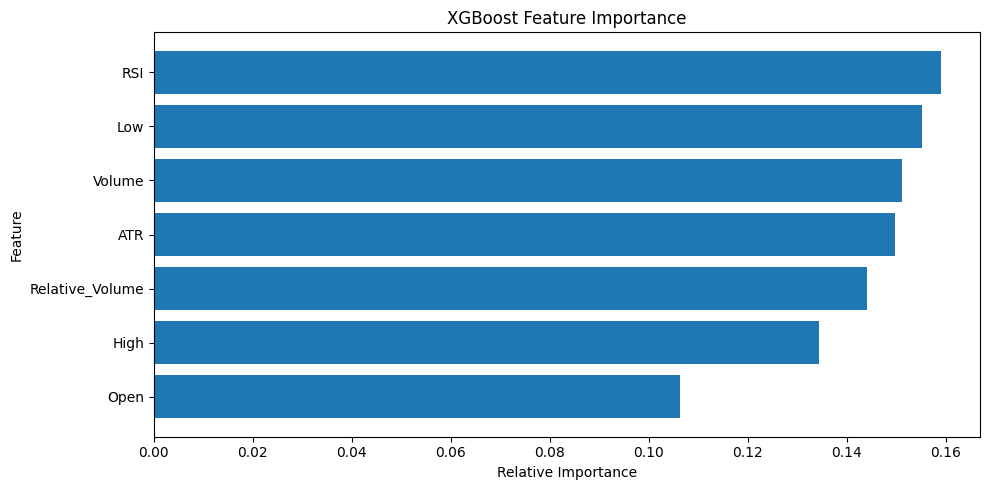


--- Generating Equity Curve ---


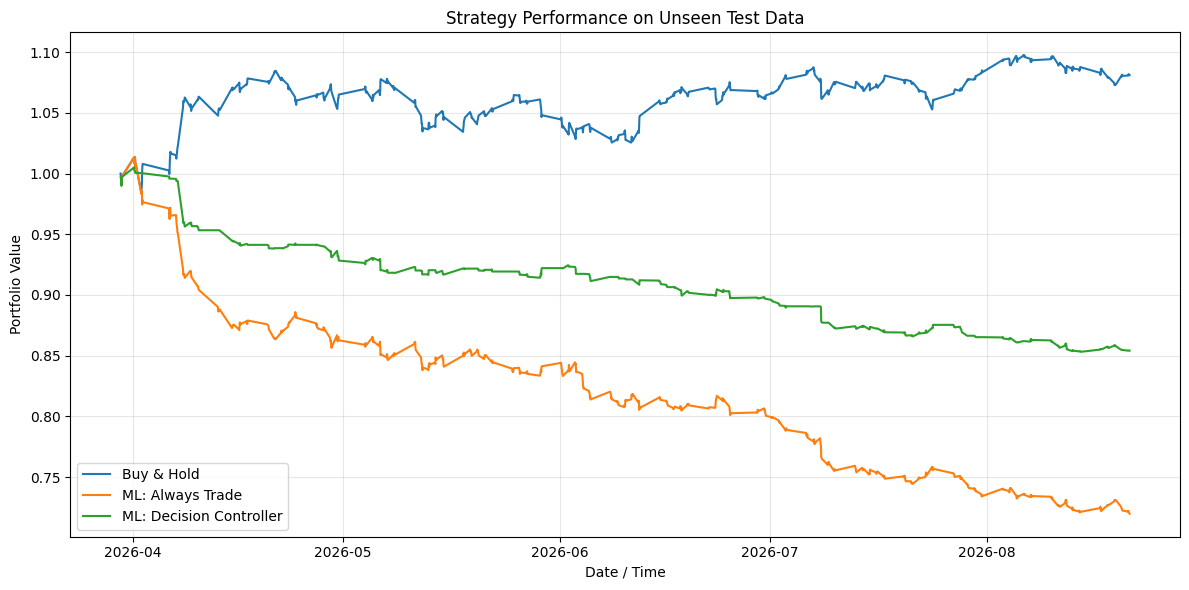

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import matplotlib.pyplot as plt


print("--- ML Model Evaluation: Unseen Test Set ---")


# ---------------------------------------------------------
# 1. Generate predictions
# ---------------------------------------------------------

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# ---------------------------------------------------------
# 2. Classification metrics
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print(f"Accuracy:   {accuracy * 100:.2f}%")
print(f"Precision:  {precision * 100:.2f}%")
print(f"Recall:     {recall * 100:.2f}%")
print(f"F1 Score:   {f1 * 100:.2f}%")
print(f"ROC-AUC:    {roc_auc:.4f}")


# ---------------------------------------------------------
# 3. Majority-class baseline
# ---------------------------------------------------------

majority_class_accuracy = y_test.value_counts(
    normalize=True
).max()

print(
    f"\nMajority-class baseline: "
    f"{majority_class_accuracy * 100:.2f}%"
)

if accuracy > majority_class_accuracy:
    print("The model performs better than the majority-class baseline.")
else:
    print("The model does not outperform the majority-class baseline.")


# ---------------------------------------------------------
# 4. Confusion matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\n--- Confusion Matrix ---")
print("                 Predicted")
print("                 DOWN  UP")
print(
    f"Actual DOWN      {cm[0, 0]:<5} {cm[0, 1]}"
)
print(
    f"Actual UP        {cm[1, 0]:<5} {cm[1, 1]}"
)


# ---------------------------------------------------------
# 5. Feature importance
# ---------------------------------------------------------

print("\n--- Feature Importance ---")

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

for _, row in feature_importance.iterrows():
    print(
        f"{row['Feature']:<18}: "
        f"{row['Importance'] * 100:.2f}%"
    )


# ---------------------------------------------------------
# 6. Plot feature importance
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 7. Plot equity curves
# ---------------------------------------------------------

print("\n--- Generating Equity Curve ---")


plt.figure(figsize=(12, 6))

plt.plot(
    backtest.index,
    backtest["Buy_Hold_Equity"],
    label="Buy & Hold"
)

plt.plot(
    backtest.index,
    backtest["ML_Equity"],
    label="ML: Always Trade"
)

plt.plot(
    backtest.index,
    backtest["Controller_Equity"],
    label="ML: Decision Controller"
)

plt.title("Strategy Performance on Unseen Test Data")
plt.xlabel("Date / Time")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()